# League Analysis

In [53]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

model_aliases = {
    "fixed_2p": "DQN Fixed",
    "fixed_3p": "DQN Fixed",
    "fixed_4p": "DQN Fixed",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Transformer",
    "deep_cfr_2p": "Deep CFR",
    "random": "Random",
}
model_order = ["DQN Fixed", "DQN Variable", "DQN Variable + Transformer", "Deep CFR", "Random"]

result_roots = [Path("results/league_results"), Path("../../results/league_results")]
results_root = next(path for path in result_roots if path.exists())

frames = []
for player_count in (2, 3, 4):
    path = results_root / f"{player_count}p" / "matches.csv"
    if not path.exists():
        continue
    data = pd.read_csv(path)
    data["player_count"] = player_count
    frames.append(data)

df = pd.concat(frames, ignore_index=True)


def split_pipe(value):
    return str(value).split("|")


def pipe_ints(value):
    return [int(part) for part in split_pipe(value)]


def mean_pipe_ints(value):
    values = pipe_ints(value)
    return sum(values) / len(values)


def average_rank_from_points(points, opponent_points_all):
    table_points = [int(points), *pipe_ints(opponent_points_all)]
    higher_scores = sum(score > points for score in table_points)
    tied_scores = sum(score == points for score in table_points)
    return higher_scores + (tied_scores + 1) / 2


df["competitor_label"] = df["competitor"].map(model_aliases)
df["opponent_labels"] = df["opponent_competitors"].apply(
    lambda names: [model_aliases[name] for name in split_pipe(names)]
)
df["opponent_mean_points"] = df["opponent_points_all"].apply(mean_pipe_ints)
df["point_margin"] = df["points"] - df["opponent_mean_points"]
df["average_rank"] = df.apply(
    lambda row: average_rank_from_points(row["points"], row["opponent_points_all"]), axis=1
)
df["won"] = df["outcome"].eq("win")
df["player_count_label"] = df["player_count"].astype(str) + "p"


In [54]:
df

,match_id,matchup_id,game_number,competitor,repetition,checkpoint_path,seat,points,pudding,opponent_competitor,...,opponent_puddings,outcome,player_count,competitor_label,opponent_labels,opponent_mean_points,point_margin,average_rank,won,player_count_label
0,match_000001,matchup_0001,1,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,0,55,3,fixed_2p,...,4,win,2,DQN Variable,[DQN Fixed],54.000000,1.000000,1.0,True,2p
1,match_000001,matchup_0001,1,fixed_2p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,1,54,4,variable_2_4,...,3,loss,2,DQN Fixed,[DQN Variable],55.000000,-1.000000,2.0,False,2p
2,match_000002,matchup_0001,2,fixed_2p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,0,60,2,variable_2_4,...,2,loss,2,DQN Fixed,[DQN Variable],64.000000,-4.000000,2.0,False,2p
3,match_000002,matchup_0001,2,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,1,64,2,fixed_2p,...,2,win,2,DQN Variable,[DQN Fixed],60.000000,4.000000,1.0,True,2p
4,match_000003,matchup_0001,3,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,0,70,1,fixed_2p,...,1,loss,2,DQN Variable,[DQN Fixed],72.000000,-2.000000,2.0,False,2p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,match_000999,matchup_0001,999,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,3,42,3,random,...,0|3|3,loss,4,DQN Variable,"[Random, DQN Variable + Transformer, DQN Fixed]",40.333333,1.666667,3.0,False,4p
35996,match_001000,matchup_0001,1000,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,0,43,2,random,...,0|4|3,win,4,DQN Variable,"[Random, DQN Fixed, DQN Variable + Transformer]",37.666667,5.333333,1.0,True,4p
35997,match_001000,matchup_0001,1000,random,1,/home/thlamz/SushiGo_MARL/random,1,34,0,variable_2_4,...,2|4|3,loss,4,Random,"[DQN Variable, DQN Fixed, DQN Variable + Trans...",40.666667,-6.666667,4.0,False,4p
35998,match_001000,matchup_0001,1000,fixed_4p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,2,42,4,variable_2_4,...,2|0|3,loss,4,DQN Fixed,"[DQN Variable, Random, DQN Variable + Transfor...",38.000000,4.000000,2.0,False,4p


## Results Loaded

In [55]:
loaded = (
    df.groupby("player_count")
      .agg(rows=("match_id", "size"), games=("match_id", "nunique"), matchups=("matchup_id", "nunique"))
      .reset_index()
)
loaded

,player_count,rows,games,matchups
0,2,20000,10000,10
1,3,12000,4000,4
2,4,4000,1000,1


## Overall Results

In [56]:
overall = (
    df.groupby(["player_count", "competitor_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
overall.style.format({
    "average_rank": "{:.2f}",
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})


,player_count,competitor_label,games,wins,losses,ties,average_rank,raw_win_rate,mean_points,mean_margin
0,2,DQN Fixed,4000,2162,1808,30,1.46,54.0%,56.45,+4.73
1,2,DQN Variable,4000,2111,1864,25,1.46,52.8%,56.30,+4.86
2,2,DQN Variable + Transformer,4000,2856,1113,31,1.29,71.4%,58.18,+8.46
3,2,Deep CFR,4000,2808,1169,23,1.30,70.2%,53.81,+7.69
4,2,Random,4000,8,3991,1,2.00,0.2%,38.13,-25.75
5,3,DQN Fixed,3000,1324,1645,31,1.67,44.1%,49.28,+8.05
6,3,DQN Variable,3000,1338,1628,34,1.67,44.6%,49.43,+8.21
7,3,DQN Variable + Transformer,3000,1288,1679,33,1.67,42.9%,49.68,+8.35
8,3,Random,3000,1,2999,0,2.99,0.0%,26.48,-24.61
9,4,DQN Fixed,1000,346,640,14,1.98,34.6%,41.93,+7.17


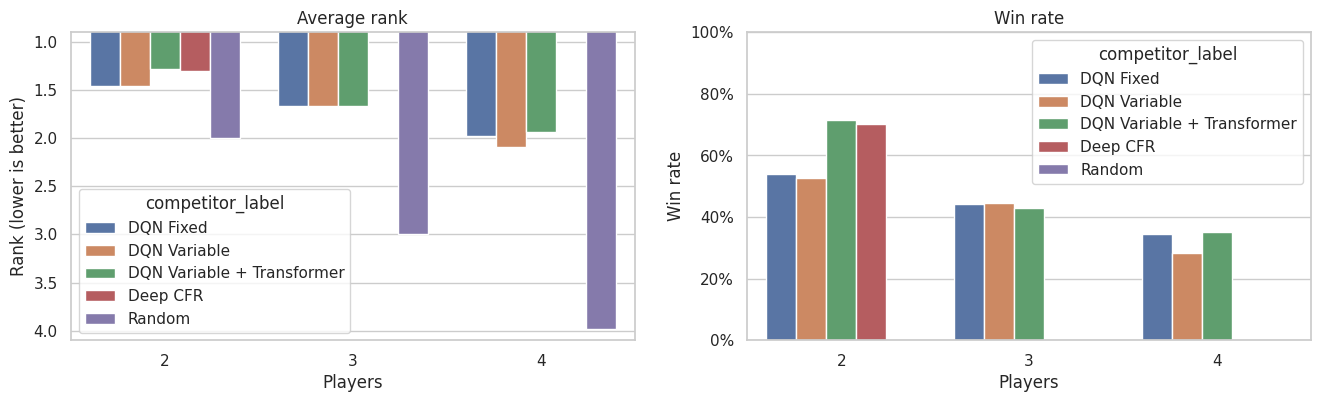

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(
    data=overall,
    x="player_count",
    y="average_rank",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Average rank")
axes[0].set_xlabel("Players")
axes[0].set_ylabel("Rank (lower is better)")
axes[0].set_ylim(df["player_count"].max() + 0.1, 0.9)

sns.barplot(
    data=overall,
    x="player_count",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Win rate")
axes[1].set_xlabel("Players")
axes[1].set_ylabel("Win rate")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

## Matchup View

In [58]:
opponent_rows = []
for row in df.itertuples(index=False):
    for opponent_label, opponent_points in zip(row.opponent_labels, pipe_ints(row.opponent_points_all)):
        opponent_rows.append({
            "player_count": row.player_count,
            "competitor_label": row.competitor_label,
            "opponent_label": opponent_label,
            "head_to_head_win": row.points > opponent_points,
            "head_to_head_tie": row.points == opponent_points,
            "head_to_head_margin": row.points - opponent_points,
        })

opponent_df = pd.DataFrame(opponent_rows)
matchup_summary = (
    opponent_df.groupby(["player_count", "competitor_label", "opponent_label"])
      .agg(
          rows=("head_to_head_win", "size"),
          head_to_head_wins=("head_to_head_win", "sum"),
          head_to_head_ties=("head_to_head_tie", "sum"),
          head_to_head_losses=("head_to_head_win", lambda wins: (~wins).sum()),
          mean_head_to_head_margin=("head_to_head_margin", "mean"),
      )
      .reset_index()
)
matchup_summary["head_to_head_losses"] = matchup_summary["head_to_head_losses"] - matchup_summary["head_to_head_ties"]
matchup_summary["non_tie_games"] = matchup_summary["head_to_head_wins"] + matchup_summary["head_to_head_losses"]
matchup_summary["non_tie_head_to_head_win_rate"] = (
    matchup_summary["head_to_head_wins"] / matchup_summary["non_tie_games"]
)
matchup_summary.style.format({
    "non_tie_head_to_head_win_rate": "{:.1%}",
    "mean_head_to_head_margin": "{:+.2f}",
})

,player_count,competitor_label,opponent_label,rows,head_to_head_wins,head_to_head_ties,head_to_head_losses,mean_head_to_head_margin,non_tie_games,non_tie_head_to_head_win_rate
0,2,DQN Fixed,DQN Variable,1000,472,53,475,+0.16,947,49.8%
1,2,DQN Fixed,DQN Variable + Transformer,1000,304,52,644,-3.17,948,32.1%
2,2,DQN Fixed,Deep CFR,1000,325,46,629,-2.83,954,34.1%
3,2,DQN Fixed,Random,1000,994,2,4,+24.77,998,99.6%
4,2,DQN Variable,DQN Fixed,1000,475,53,472,-0.16,947,50.2%
5,2,DQN Variable,DQN Variable + Transformer,1000,302,60,638,-2.99,940,32.1%
6,2,DQN Variable,Deep CFR,1000,322,50,628,-2.91,950,33.9%
7,2,DQN Variable,Random,1000,995,1,4,+25.50,999,99.6%
8,2,DQN Variable + Transformer,DQN Fixed,1000,644,52,304,+3.17,948,67.9%
9,2,DQN Variable + Transformer,DQN Variable,1000,638,60,302,+2.99,940,67.9%


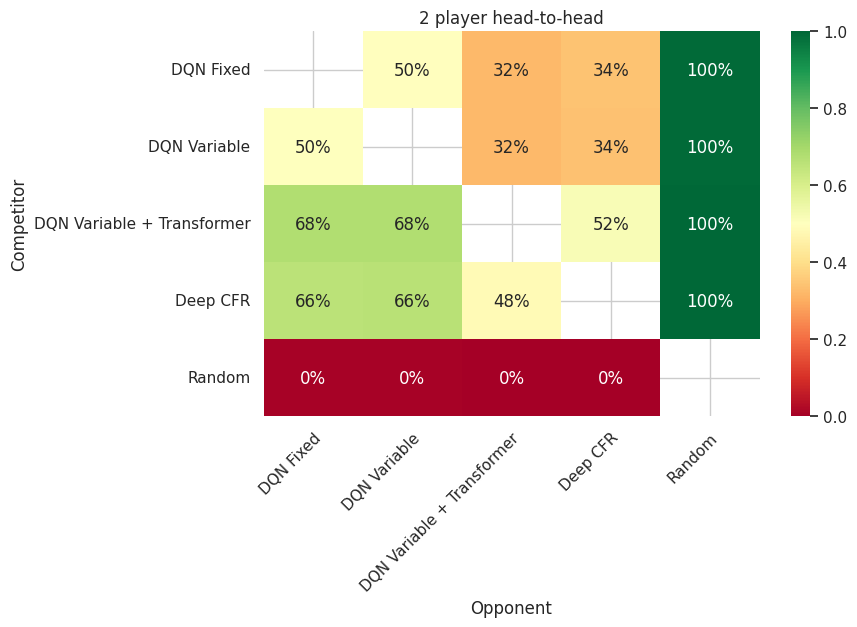

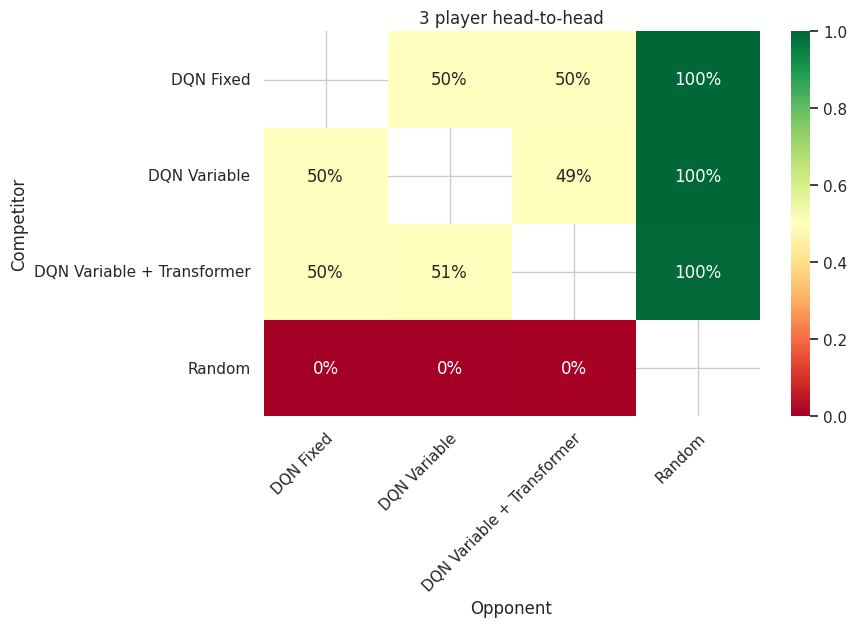

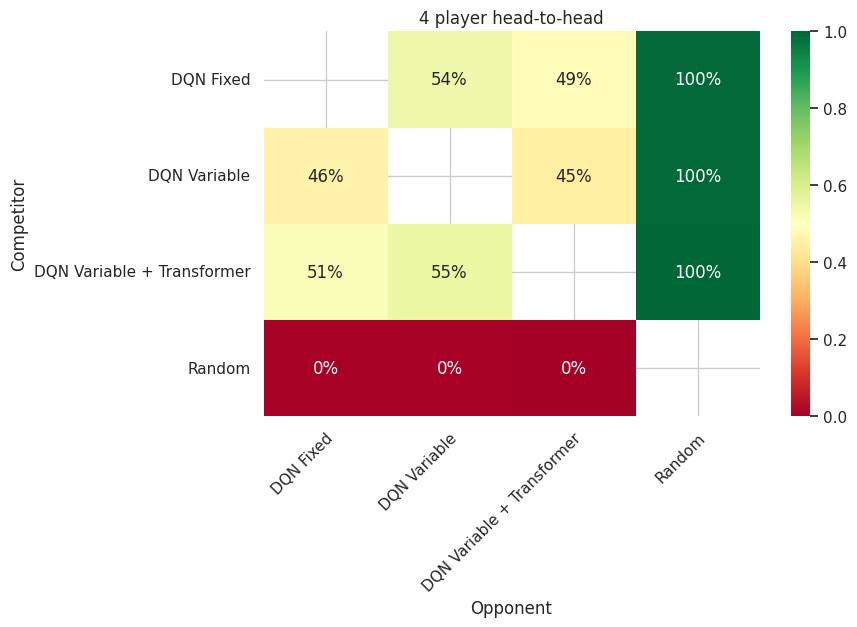

<Figure size 640x480 with 0 Axes>

In [71]:
for player_count in (2, 3, 4):
    player_models = [model for model in model_order if model != "Deep CFR" or player_count == 2]
    matrix = matchup_summary[matchup_summary["player_count"] == player_count].pivot(
        index="competitor_label", columns="opponent_label", values="non_tie_head_to_head_win_rate"
    ).reindex(index=player_models, columns=player_models)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=ax)
    ax.set_title(f"{player_count} player head-to-head")
    ax.set_xlabel("Opponent")
    # 45 degree X label
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_ylabel("Competitor")
    plt.show()
plt.tight_layout()

## Repetition Variance

In [60]:
repetition_results = (
    df.groupby(["player_count", "competitor_label", "repetition"])
      .agg(
          games=("match_id", "size"),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
      )
      .reset_index()
)

repetition_variance = (
    repetition_results.groupby(["player_count", "competitor_label"])
      .agg(
          repetitions=("repetition", "nunique"),
          mean_average_rank=("average_rank", "mean"),
          average_rank_variance=("average_rank", "var"),
          mean_win_rate=("raw_win_rate", "mean"),
          win_rate_variance=("raw_win_rate", "var"),
      )
      .reset_index()
)
repetition_variance[["average_rank_variance", "win_rate_variance"]] = repetition_variance[
    ["average_rank_variance", "win_rate_variance"]
].fillna(0)
repetition_variance.style.format({
    "mean_average_rank": "{:.2f}",
    "average_rank_variance": "{:.4f}",
    "mean_win_rate": "{:.1%}",
    "win_rate_variance": "{:.4f}",
})


,player_count,competitor_label,repetitions,mean_average_rank,average_rank_variance,mean_win_rate,win_rate_variance
0,2,DQN Fixed,1,1.46,0.0000,54.0%,0.0000
1,2,DQN Variable,1,1.46,0.0000,52.8%,0.0000
2,2,DQN Variable + Transformer,1,1.29,0.0000,71.4%,0.0000
3,2,Deep CFR,1,1.30,0.0000,70.2%,0.0000
4,2,Random,1,2.00,0.0000,0.2%,0.0000
5,3,DQN Fixed,1,1.67,0.0000,44.1%,0.0000
6,3,DQN Variable,1,1.67,0.0000,44.6%,0.0000
7,3,DQN Variable + Transformer,1,1.67,0.0000,42.9%,0.0000
8,3,Random,1,2.99,0.0000,0.0%,0.0000
9,4,DQN Fixed,1,1.98,0.0000,34.6%,0.0000


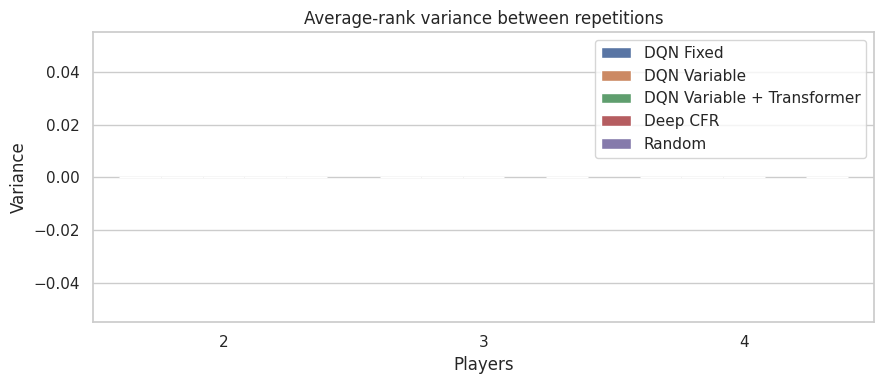

In [61]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=repetition_variance,
    x="player_count",
    y="average_rank_variance",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
)
plt.title("Average-rank variance between repetitions")
plt.xlabel("Players")
plt.ylabel("Variance")
plt.legend(title="")
plt.tight_layout()


## Seat Effects

In [62]:
seat_results = (
    df.groupby(["player_count", "competitor_label", "seat"])
      .agg(
          games=("match_id", "size"),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
seat_results.style.format({
    "average_rank": "{:.2f}",
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})


,player_count,competitor_label,seat,games,average_rank,raw_win_rate,mean_margin
0,2,DQN Fixed,0,1970,1.45,54.9%,+4.86
1,2,DQN Fixed,1,2030,1.46,53.3%,+4.61
2,2,DQN Variable,0,2035,1.44,54.2%,+5.16
3,2,DQN Variable,1,1965,1.47,51.3%,+4.55
4,2,DQN Variable + Transformer,0,2005,1.29,71.3%,+8.48
5,2,DQN Variable + Transformer,1,1995,1.29,71.5%,+8.44
6,2,Deep CFR,0,2001,1.29,71.4%,+7.95
7,2,Deep CFR,1,1999,1.32,69.0%,+7.44
8,2,Random,0,1989,2.00,0.2%,-25.67
9,2,Random,1,2011,2.00,0.2%,-25.83


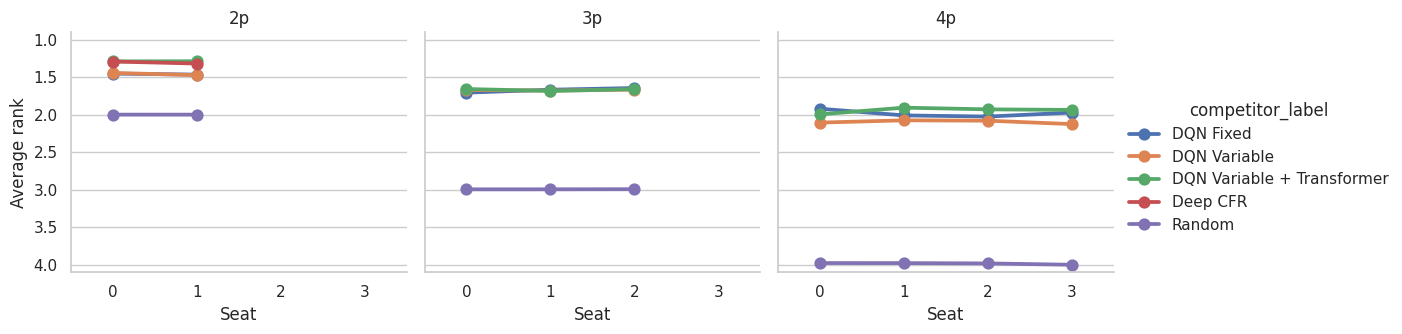

In [69]:
grid = sns.catplot(
    data=seat_results,
    kind="point",
    x="seat",
    y="average_rank",
    hue="competitor_label",
    hue_order=model_order,
    col="player_count",
    errorbar=None,
    height=3.5,
    aspect=1.1,
)
grid.set_axis_labels("Seat", "Average rank")
grid.set_titles("{col_name}p")
for ax in grid.axes.flat:
    ax.set_ylim(df["player_count"].max() + 0.1, 0.9)


## Training Metrics

In [64]:
metrics_candidates = [Path("results/league"), Path("../../results/league")]
metrics_root = next(path for path in metrics_candidates if path.exists())

checkpoint_aliases = {
    "fixed_2p": "DQN Fixed 2 Players",
    "fixed_3p": "DQN Fixed 3 Players",
    "fixed_4p": "DQN Fixed 4 Players",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
}

training_metrics = []
for model, alias in checkpoint_aliases.items():
    for metrics_path in sorted((metrics_root / model).glob("repetition_*/metrics.csv")):
        metrics = pd.read_csv(metrics_path)
        metrics["checkpoint"] = alias
        metrics["repetition"] = int(metrics_path.parent.name.removeprefix("repetition_"))
        training_metrics.append(metrics)

training_df = pd.concat(training_metrics, ignore_index=True)
training_df["loss_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["loss"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)
training_df["return_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["mean_episode_return"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)

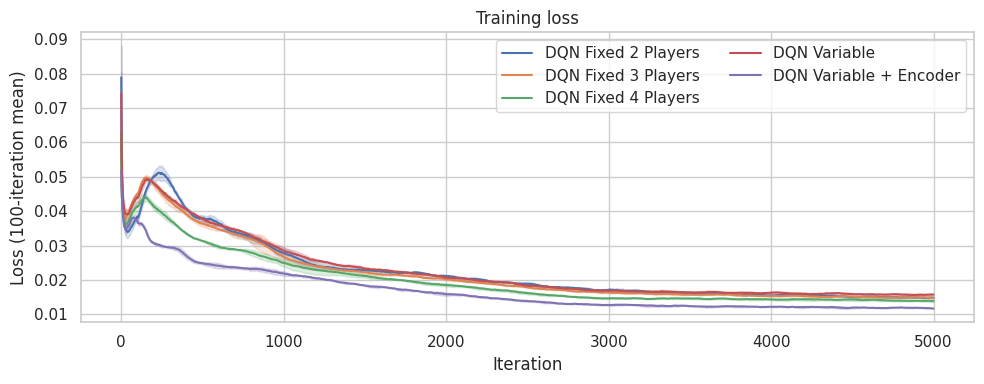

In [65]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="loss_smoothed", hue="checkpoint", errorbar="sd")
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()

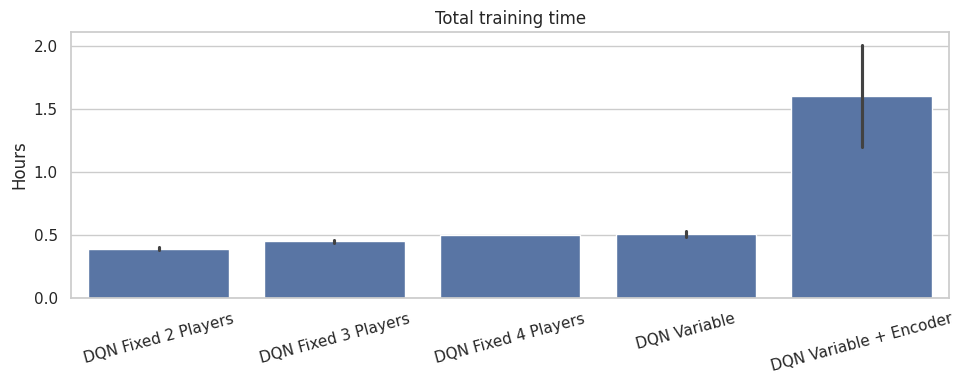

In [66]:
training_time = training_df.groupby(["checkpoint", "repetition"], as_index=False)["elapsed_seconds"].max()
training_time["hours"] = training_time["elapsed_seconds"] / 3600

plt.figure(figsize=(10, 4))
sns.barplot(data=training_time, x="checkpoint", y="hours", errorbar="sd")
plt.title("Total training time")
plt.xlabel("")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.tight_layout()

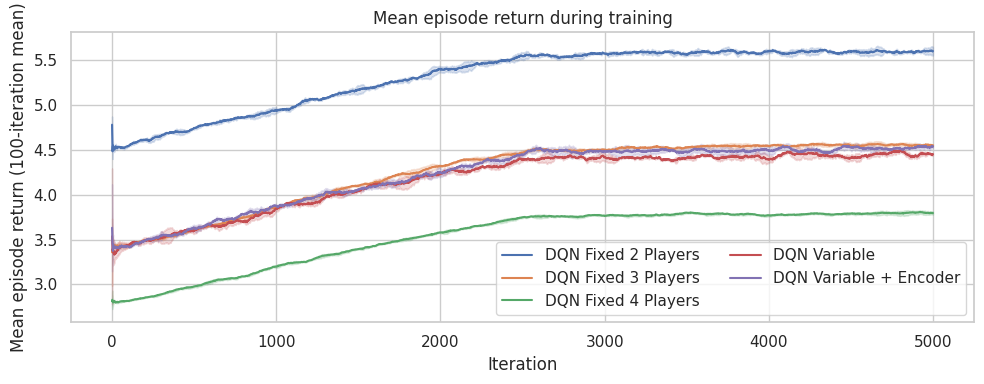

In [67]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="return_smoothed", hue="checkpoint", errorbar="sd")
plt.title("Mean episode return during training")
plt.xlabel("Iteration")
plt.ylabel("Mean episode return (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()